# **XI) MPE Analysis**


### **1) Summary Stats**

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np

In [2]:
fed = pd.read_csv("data/stocktwits/FED_class.csv")
macro = pd.read_csv("data/stocktwits/MACRO_class.csv")
df = pd.concat([fed, macro])

# Pre-processing
df['class'] = pd.to_numeric(df['class'], errors='coerce')
df = df.dropna(subset=['class'])

# Define Mapping and Stance Categories
mapping = {-2: "Very Hawkish (-2)", -1: "Hawkish (-1)", 
           0: "Neutral (0)", +1: "Dovish (+1)", +2: "Very Dovish (+2)"}
df['Stance'] = df['class'].map(mapping)

# Summary Table
summary_table = df.groupby('Stance').agg(
    Obs=('id_', 'count'),
    Likes=('nb_likes', 'mean'),
    Reshares=('nb_reshares', 'mean')
).reindex(["Very Hawkish (-2)", "Hawkish (-1)", "Neutral (0)", "Dovish (+1)", "Very Dovish (+2)"])

# Metrics
summary_table['Share (%)'] = (summary_table['Obs'] / len(df) * 100).round(2)
summary_table['Avg. Engag.'] = summary_table['Likes'] + summary_table['Reshares']

# TOTAL row
total_row = pd.DataFrame({
    'Obs': [len(df)],
    'Likes': [df['nb_likes'].mean()],
    'Reshares': [df['nb_reshares'].mean()],
    'Share (%)': [100.00],
    'Avg. Engag.': [df['nb_likes'].mean() + df['nb_reshares'].mean()]
}, index=['TOTAL / Average'])

final_table = pd.concat([summary_table, total_row])
final_table = final_table[['Obs', 'Share (%)', 'Likes', 'Reshares', 'Avg. Engag.']]

display(final_table)

,Obs,Share (%),Likes,Reshares,Avg. Engag.
Very Hawkish (-2),238,0.20,1.277311,0.046218,1.323529
Hawkish (-1),2526,2.13,0.880443,0.076801,0.957245
Neutral (0),113695,95.96,0.291499,0.021857,0.313356
Dovish (+1),1930,1.63,0.505699,0.029534,0.535233
Very Dovish (+2),90,0.08,0.800000,0.077778,0.877778
TOTAL / Average,118479,100.00,0.309911,0.023245,0.333156


In [3]:
# Print as LaTeX 
latex_code = final_table.to_latex(
    index=True,
    column_format='l r r c c c',
    float_format="%.2f",
    caption="Descriptive Statistics of the Monetary Policy Expectations (MPE) Index",
    label="tab:mpe_summary_stats",
    bold_rows=True,
    header=['Obs. ($N$)', 'Share (%)', 'Avg. Likes', 'Avg. Reshares', 'Avg. Engag.']
)

print(latex_code)

\begin{table}
\caption{Descriptive Statistics of the Monetary Policy Expectations (MPE) Index}
\label{tab:mpe_summary_stats}
\begin{tabular}{l r r c c c}
\toprule
 & Obs. ($N$) & Share (%) & Avg. Likes & Avg. Reshares & Avg. Engag. \\
\midrule
\textbf{Very Hawkish (-2)} & 238 & 0.20 & 1.28 & 0.05 & 1.32 \\
\textbf{Hawkish (-1)} & 2526 & 2.13 & 0.88 & 0.08 & 0.96 \\
\textbf{Neutral (0)} & 113695 & 95.96 & 0.29 & 0.02 & 0.31 \\
\textbf{Dovish (+1)} & 1930 & 1.63 & 0.51 & 0.03 & 0.54 \\
\textbf{Very Dovish (+2)} & 90 & 0.08 & 0.80 & 0.08 & 0.88 \\
\textbf{TOTAL / Average} & 118479 & 100.00 & 0.31 & 0.02 & 0.33 \\
\bottomrule
\end{tabular}
\end{table}



### **2) Word Cloud**

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maximen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/maximen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


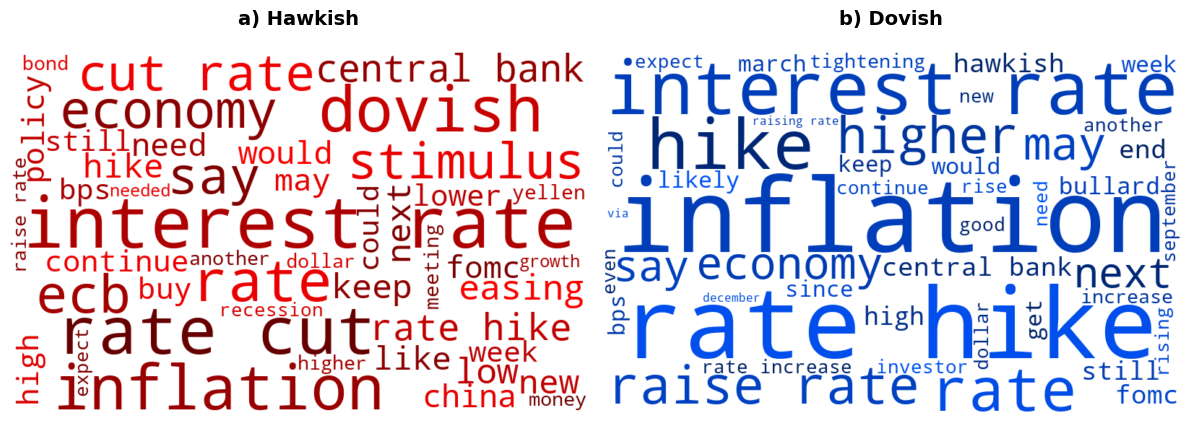

In [4]:
# RESOURCES
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
eng_stopwords = set(stopwords.words('english'))

fed = pd.read_csv("data/stocktwits/FED_class.csv")
macro = pd.read_csv("data/stocktwits/MACRO_class.csv")
df = pd.concat([fed, macro])

# Cleaning pipeline
def professional_clean(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\$\w+|@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text.lower())
    words = text.split()
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in eng_stopwords and len(w) > 2]
    return " ".join(cleaned)

domain_noise = {'fed', 'macro', 'stock', 'market', 'price', 'today', 'will', 'going', 
                'time', 'now', 'amp', 'look', 'see', 'think', 'year', 'month'}
final_stopwords = eng_stopwords.union(domain_noise)

# Prepare
hawkish_corpus = professional_clean(" ".join(df[df['class'] > 0]['body'].astype(str)))
dovish_corpus = professional_clean(" ".join(df[df['class'] < 0]['body'].astype(str)))

# CUSTOM COLOR FUNCTIONS FOR MAXIMUM BOLDNESS
# These force the cloud to use only the darkest 60% of the color range
def dark_red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return f"hsl(0, 100%, {np.random.randint(20, 50)}%)" # Deep Reds

def dark_blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return f"hsl(220, 100%, {np.random.randint(20, 50)}%)" # Deep Blues

# 6. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Hawkish Cloud - Bold & Dark Red
wc_hawk = WordCloud(width=800, height=500, 
                    background_color='white', 
                    max_words=45, 
                    min_font_size=15,    # Larger minimum size for visibility
                    font_step=2,         # Makes font scaling more aggressive
                    prefer_horizontal=0.9,
                    stopwords=final_stopwords
                   ).generate(hawkish_corpus)

ax1.imshow(wc_hawk.recolor(color_func=dark_red_color_func, random_state=42), interpolation='bilinear')
ax1.set_title("a) Hawkish", fontsize=14, fontweight='black', pad=20)
ax1.axis("off")

# Dovish Cloud - Bold & Dark Blue
wc_dove = WordCloud(width=800, height=500, 
                    background_color='white', 
                    max_words=45, 
                    min_font_size=15,
                    font_step=2,
                    prefer_horizontal=0.9,
                    stopwords=final_stopwords
                   ).generate(dovish_corpus)

ax2.imshow(wc_dove.recolor(color_func=dark_blue_color_func, random_state=42), interpolation='bilinear')
ax2.set_title("b) Dovish", fontsize=14, fontweight='black', pad=20)
ax2.axis("off")
plt.tight_layout()
plt.savefig("figures/word_cloud.pdf")
plt.show()

### **3) Narratives: Inflation vs. MPE**

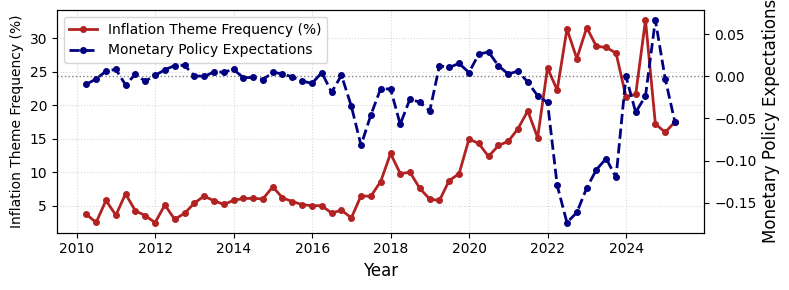

In [5]:
fed = pd.read_csv("data/stocktwits/FED_class.csv")
macro = pd.read_csv("data/stocktwits/MACRO_class.csv")
df = pd.concat([fed, macro])

# Pre-processing
df['date'] = pd.to_datetime(df['date'])
df['body'] = df['body'].astype(str).str.lower()
df['class'] = pd.to_numeric(df['class'], errors='coerce')
df = df.dropna(subset=['class', 'date'])

# Inflation theme
inflation_terms = ['inflation', 'cpi', 'pce', 'ppi', 'sticky', 'prices', 'hyperinflation', 'wage growth', 'cost of living']
df['is_inflation'] = df['body'].apply(lambda x: any(word in x for word in inflation_terms))

# QUARTERLY AGGREGATION
# Mean of 'is_inflation' = Percentage of messages
# Mean of 'class' = The MPE Index value
evolution = df.set_index('date').resample('QE').agg({
    'is_inflation': 'mean',
    'class': 'mean'
})

evolution['is_inflation'] *= 100  # Convert to percentage

# Plot
fig, ax1 = plt.subplots(figsize=(8, 3))

# Primary Axis: Inflation Narrative Volume
color_inf = 'firebrick'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Inflation Theme Frequency (%)')
ax1.plot(evolution.index, evolution['is_inflation'], color=color_inf, linewidth=2, 
         label='Inflation Theme Frequency (%)', marker='o', markersize=4)
ax1.tick_params(axis='y')
ax1.grid(True, linestyle=':', alpha=0.5)

# Secondary Axis: MPE Index Value
ax2 = ax1.twinx()
color_idx = 'navy'
ax2.set_ylabel('Monetary Policy Expectations', fontsize=12)
ax2.plot(evolution.index, evolution['class'], marker='o', markersize=4, color=color_idx, linewidth=2, 
         label='Monetary Policy Expectations', linestyle='--')
ax2.tick_params(axis='y')

# Baseline
ax2.axhline(0, color='black', linewidth=1, alpha=0.5, linestyle=':')

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig("figures/inflation_vs_index_evolution.pdf")
plt.show()